# FITTING NOTEBOOK - NIRSpec

In [1]:
# ALWAYS RUN THE FIRST THREE CELLS
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
# import transitspectroscopy as ts
from tqdm import tqdm
import pandas as pd
import csv
from extract_data import tspec_nirspec, eureka_dat

import seaborn as sns
sns.set_style('ticks')

In [2]:
# Open data file (transitspectroscopy output)
# t, f_wl, ferr_wl, wl, spec_lcs, bin_slc = tspec_nirspec('/media/peng/KINGSTON/_jw03385002001_toi1130_nrs1_spectrum.pkl', 10)
t, f_wl, ferr_wl, wl, spec_lcs = eureka_dat('/media/peng/KINGSTON/toi1130b_nrs1_LCData.h5')

In [16]:
# Define planetary parameters
# TOI-1130b
per = 4.07             # Period (Days)
t0 =  60542.57          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# # TOI-1468c
# per = 15.532477             # Period (Days)
# t0 = 60506.06          # Mid-Transit Time (BJD)
# a = 49.8                  # Semimajor Axis (a/R*)
# b = 0.664                 # Impact Parameter
# ecc = 0.111             # Eccentricity
# omega = 130             # Argument of Periastron (Degrees)

# Define planet and instrument name
pn = 'TOI-1130b_eureka'
itm = 'NRS1'

# White Light Curves

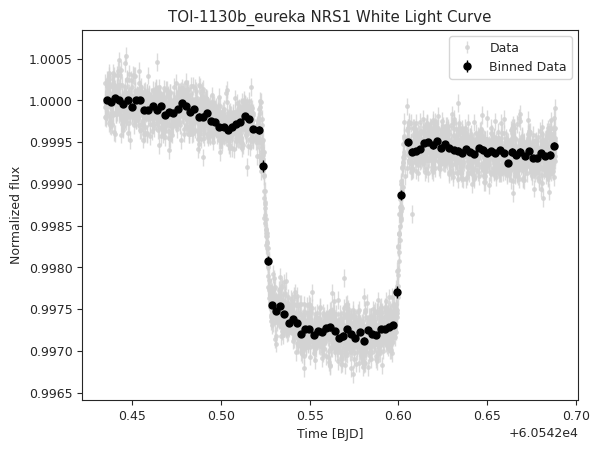

In [17]:
# Define time and flux data points - white light curves
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized flux')

# # Define root-mean-squared values
# rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
# rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [19]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [20]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [[per, 0.01], [t0, 0.2], [48, 51], [0.4, 0.8], [-5., 5.], [-5., 5.], [0.01, 0.3], [60., 230.], [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
#--------------------------------------------------------------------------------------------------

# # Linear
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#           'theta0_'+itm]

# dists = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform']

# hyperps = [[per, 0.01], [t0, 0.2], [13., 14.], [-1., 1.], [-3., 3.], [-3., 3.], [0.01, 0.03], [100., 200.], [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#           [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [[per, 0.01], [t0, 0.2], [48, 51], [0.4, 0.8], [-5., 5.], [-5., 5.], [0.01, 0.3], [60., 230.], [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
# # --------------------------------------------------------------------------------------------------

# Linear + GP
params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
           'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

dists = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform', 'loguniform', 'loguniform']

hyperps = [[per, 0.01], [t0, 0.2], [13., 14.], [-1., 1.], [-3., 3.], [-3., 3.], [0.01, 0.03], [100., 200.], [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
           [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]


priors = juliet.generate_priors(params, dists, hyperps) 

In [ ]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit')
# #---------------------------------------------------------------------------------------------

# # Linear
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_GP')
# #---------------------------------------------------------------------------------------------

# Linear + GP
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 6, verbose = True, n_live_points = 1000)
print('done')

7033it [01:26, 64.86it/s, batch: 0 | bound: 4 | nc: 34 | ncall: 151730 | eff(%):  4.605 | loglstar:   -inf < 19116.809 <    inf | logz: 19105.583 +/-    nan | dlogz: 143.286 >  0.010]   

In [ ]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

In [ ]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.nanmedian(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' '+itm+ ' White Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+pn+'_'+itm+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+pn+'_'+itm+'_residuals.png')
plt.show()

In [ ]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+pn+'_'+itm+'_corner.png')
plt.show()

In [ ]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
# print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
print('With linear + GP:', results.posteriors['lnZ'])

In [24]:
# Get transit depth for white light curve
td_list = (results.posteriors['posterior_samples']['p_p1']**2) * 100

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Transit Depth:', td, '\n', 
      'Errors:', tderr)

Transit Depth: 0.2166471182659463 
 Errors: 0.004233196717110537


# Spectroscopic Light Curves

In [8]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

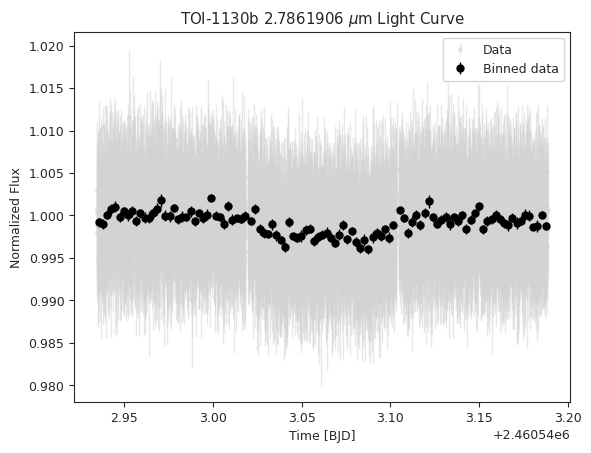

In [5]:
# Test wavelength/wavelength list
trial_wl = 2.7861906

# Uncomment to use native resolution
# f_s = spec_lcs[trial_wl]['f']
# ferr_s = spec_lcs[trial_wl]['ferr']

# Uncomment to use bin_slc
f_s = bin_slc[trial_wl]['f']
ferr_s = bin_slc[trial_wl]['ferr']

# Don't need to normalize since it's already normalized in the dict, so just bin
tbin, fsbin, ferrsbin = juliet.bin_data(t, f_s, 25)

plt.errorbar(t, f_s, yerr = ferr_s, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data', zorder = 1)
plt.errorbar(tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)
plt.title(pn+' '+str(round(trial_wl, 7))+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized Flux')
plt.legend()

plt.show()

In [12]:
# For now, only define parameters + linear model for NRS1 and 2
# t0 = 2460543.0631091068 # for NRS1
# t0 = 2460543.0623039217 # for NRS2

# u1 = -1.0117974286 # for NRS2
# u2 = 1.6939836238

params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
           'GP_sigma_'+itm, 'GP_rho_'+itm]

dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'loguniform', 'loguniform']

hyperps = [per, t0, a, b, [-5., 5.], [-5., 5.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
           [1e-8, 1e2], [1e-8, 1e3]]

priors = juliet.generate_priors(params, dists, hyperps)

# Put data into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 GP_regressors_lc = GP_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+str(round(trial_wl, 7))+'_fit_sunspot')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

23797it [03:18, 119.77it/s, batch: 1 | bound: 2 | nc: 1 | ncall: 530021 | eff(%):  4.280 | loglstar: 6771.197 < 6774.534 < 6773.211 | logz: 6759.289 +/-  0.117 | stop:  0.994]           


done


In [13]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_s**2)

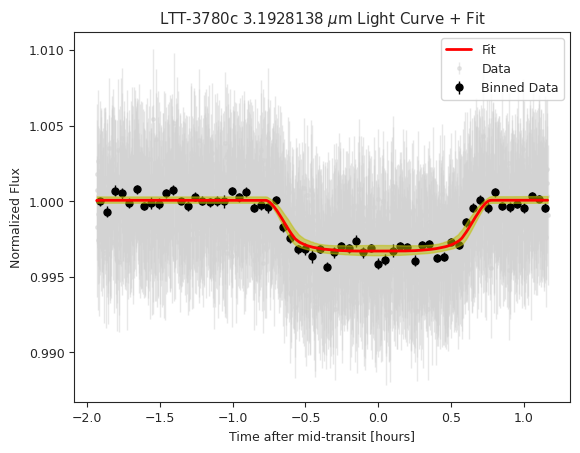

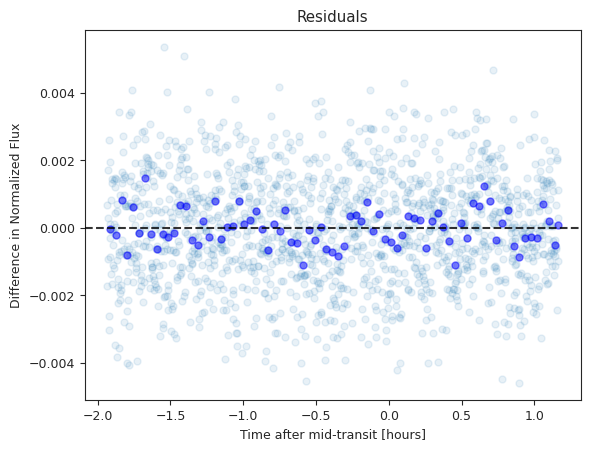

In [16]:
# Normalize time so it's relative to mid-transit
norm_t = (t - t0) * 24
norm_tbin = (tbin - t0) * 24

# Scatter data
plt.errorbar(norm_t, f_s, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+ ' '+str(round(trial_wl, 7))+ ' $\mu$m Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_s - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_residuals.png')
plt.show()

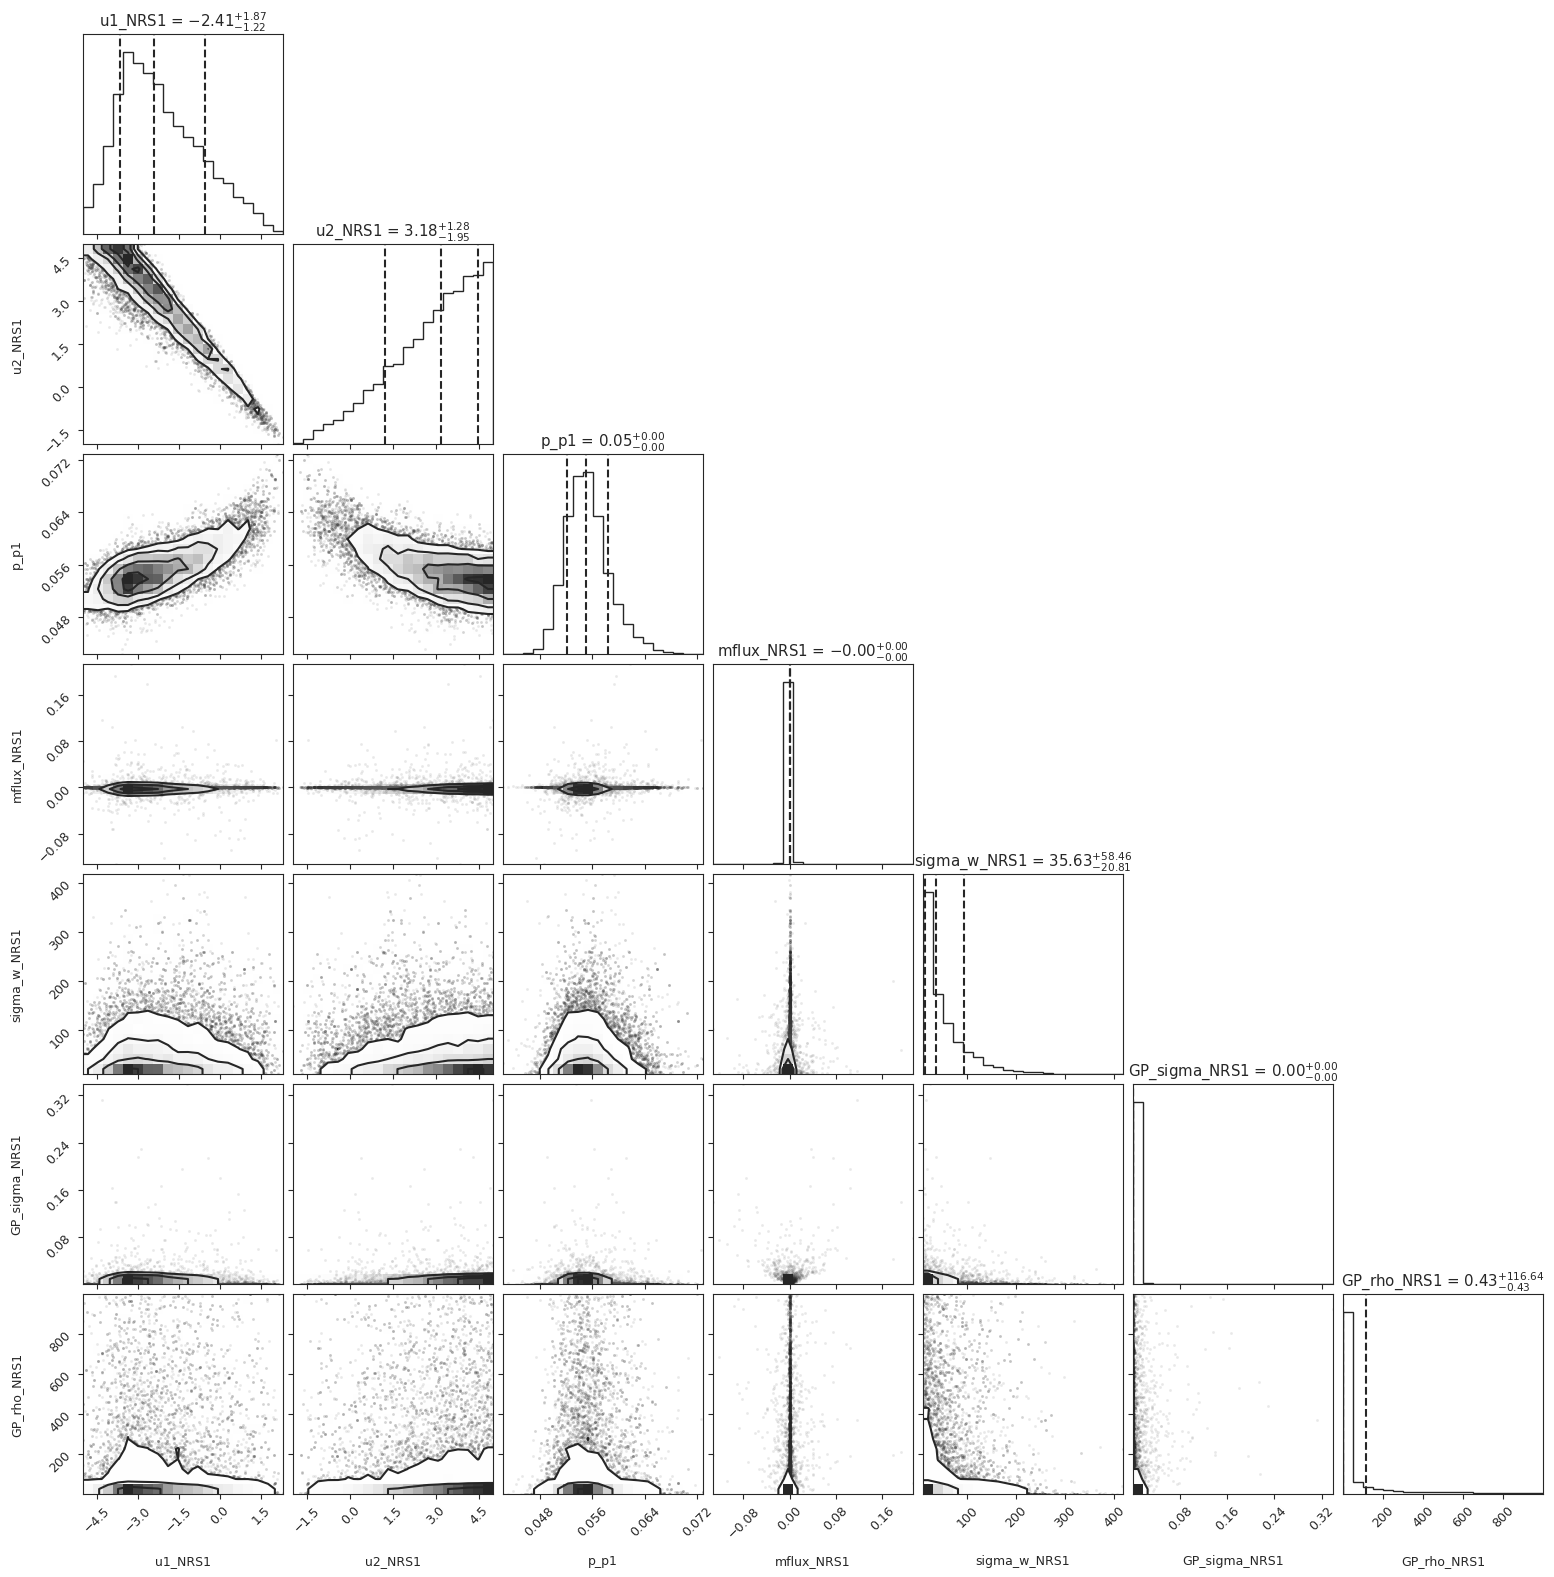

Log Evidence: 6759.308822670807


In [17]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_corner.png')
plt.show()

print('Log Evidence:', results.posteriors['lnZ'])

In [18]:
# Get best fit value of p_p1 and convert to transit depth
td_list = (results.posteriors['posterior_samples']['p_p1']**2)

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Wavelength:', trial_wl, '\n',
      'Transit Depth:', td, '\n', 
      'Errors:', tderr)

Wavelength: 3.1928138 
 Transit Depth: 0.0030981940092390985 
 Errors: 0.00045711259818334967


In [18]:
# Run speclc_fit.py which loops through all indices of spec_lcs or any similar dict and fits each light curve
%run nirspec_speclc_fit-Cluster.py

28468it [02:15, 209.51it/s, batch: 2 | bound: 1 | nc: 1 | ncall: 564080 | eff(%):  4.857 | loglstar: 6013.863 < 6017.390 < 6014.464 | logz: 5998.815 +/-  0.110 | stop:  0.959]              
2407it [00:09, 242.65it/s, batch: 0 | bound: 0 | nc: 3 | ncall: 10731 | eff(%): 20.518 | loglstar:   -inf < -71116.212 <    inf | logz: -71126.219 +/-  0.100 | dlogz: 77643.837 >  0.010]   

Exception while calling loglikelihood function:Exception while calling loglikelihood function:

KeyboardInterrupt: 

# Transmission Spectrum

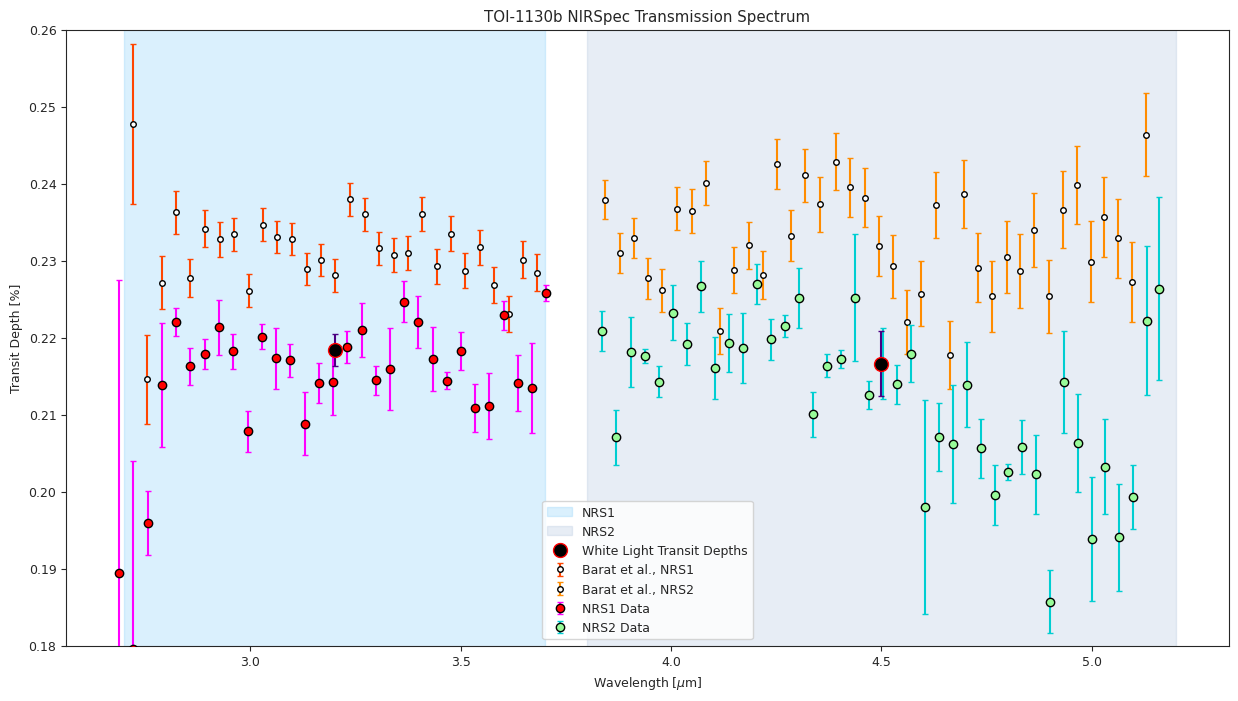

In [5]:
fig = plt.figure(figsize = (15, 8))

# Plot wavlength ranges for each detector
nrs1, nrs2 = [2.7, 3.7], [3.8, 5.2]
ys = [0.10, 0.40]   # Set ylim such that this spans the entire screen
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.3, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.3, zorder = 1, label = 'NRS2')

# Plot transit depths from white light curves
central_bins = [3.2, 4.5]
central_td = [0.2184226235891346, 0.2166471182659463]
central_tderr = [0.0021033446739131805, 0.004233196717110537]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)

# Plot spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1', zorder = 1)
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2', zorder = 1)


# NRS 1
nrs1_data = pd.read_csv('TOI-1130b_NRS1-Cluster.csv')
nrs1_wl = np.array(nrs1_data['wavelength'])
nrs1_td = np.array(nrs1_data['transit depth'])
nrs1_tderr = np.array(nrs1_data['transit depth error'])

nrs1_wl, nrs1_td, nrs1_tderr = juliet.bin_data(nrs1_wl, nrs1_td, 5)
plt.errorbar(nrs1_wl, nrs1_td, yerr = nrs1_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'NRS1 Data', zorder = 8)

# NRS 2
nrs2_data = pd.read_csv('TOI-1130b_NRS2-Cluster.csv')
nrs2_wl = np.array(nrs2_data['wavelength'])
nrs2_td = np.array(nrs2_data['transit depth'])
nrs2_tderr = np.array(nrs2_data['transit depth error'])

nrs2_wl, nrs2_td, nrs2_tderr = juliet.bin_data(nrs2_wl, nrs2_td, 5)
plt.errorbar(nrs2_wl, nrs2_td, yerr = nrs2_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'palegreen', mec = 'k', color = 'darkturquoise', label = 'NRS2 Data', zorder = 8)


plt.title(pn+' NIRSpec Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.ylim(0.18, 0.26)
plt.legend()
plt.show()